# Feature Engineering

In [2905]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [2906]:
def zero_pct(df, cols):
    """Share of zero values per column, sorted descending."""
    return (df[cols] == 0).mean().to_frame("ZERO_PCT").sort_values("ZERO_PCT", ascending=False)

In [2907]:
# PATH DEFINITIONS
BASE_DIR = Path().resolve().parent

DATA_DIR = BASE_DIR / "data"
CLEAN_DATA_DIR = DATA_DIR / "data_clean"

In [2908]:
# TODO: revisit this read approach — see cleaning.py for a cleaner pattern
df_clean = pd.read_csv(CLEAN_DATA_DIR / "train_clean.csv", keep_default_na=False, na_values=[""])

# Classification and Overview

In [2909]:
df_clean.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE,HASGARAGE,HASPOOL
0,1,60,RL,65.0,8450.0,PAVE,NA,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706.0,UNF,0.0,150.0,856.0,GASA,EX,Y,SBRKR,856.0,854.0,0.0,1710.0,1,0,2,1,3,1,GD,8,TYP,0,NA,ATTCHD,RFN,2,548.0,TA,TA,Y,0.0,61.0,0.0,0.0,0.0,NA,NA,0,2,2008,WD,NORMAL,208500.0,True,False
1,2,20,RL,80.0,9600.0,PAVE,NA,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,None,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978.0,UNF,0.0,284.0,1262.0,GASA,EX,Y,SBRKR,1262.0,0.0,0.0,1262.0,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,RFN,2,460.0,TA,TA,Y,298.0,0.0,0.0,0.0,0.0,NA,NA,0,5,2007,WD,NORMAL,181500.0,True,False
2,3,60,RL,68.0,11250.0,PAVE,NA,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486.0,UNF,0.0,434.0,920.0,GASA,EX,Y,SBRKR,920.0,866.0,0.0,1786.0,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,RFN,2,608.0,TA,TA,Y,0.0,42.0,0.0,0.0,0.0,NA,NA,0,9,2008,WD,NORMAL,223500.0,True,False
3,4,70,RL,60.0,9550.0,PAVE,NA,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,None,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216.0,UNF,0.0,540.0,756.0,GASA,GD,Y,SBRKR,961.0,756.0,0.0,1717.0,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,UNF,3,642.0,TA,TA,Y,0.0,35.0,272.0,0.0,0.0,NA,NA,0,2,2006,WD,ABNORML,140000.0,True,False
4,5,60,RL,84.0,14260.0,PAVE,NA,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655.0,UNF,0.0,490.0,1145.0,GASA,EX,Y,SBRKR,1145.0,1053.0,0.0,2198.0,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,RFN,3,836.0,TA,TA,Y,192.0,84.0,0.0,0.0,0.0,NA,NA,0,12,2008,WD,NORMAL,250000.0,True,False


In [2910]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1412 non-null   int64  
 1   MSSUBCLASS     1412 non-null   int64  
 2   MSZONING       1412 non-null   str    
 3   LOTFRONTAGE    1412 non-null   float64
 4   LOTAREA        1412 non-null   float64
 5   STREET         1412 non-null   str    
 6   ALLEY          1412 non-null   str    
 7   LOTSHAPE       1412 non-null   str    
 8   LANDCONTOUR    1412 non-null   str    
 9   UTILITIES      1412 non-null   str    
 10  LOTCONFIG      1412 non-null   str    
 11  LANDSLOPE      1412 non-null   str    
 12  NEIGHBORHOOD   1412 non-null   str    
 13  CONDITION1     1412 non-null   str    
 14  CONDITION2     1412 non-null   str    
 15  BLDGTYPE       1412 non-null   str    
 16  HOUSESTYLE     1412 non-null   str    
 17  OVERALLQUAL    1412 non-null   int64  
 18  OVERALLCOND    1412

In [2911]:
ord_cols = [
    "LOTSHAPE", "UTILITIES", "LANDSLOPE", "OVERALLQUAL",
    "OVERALLCOND", "EXTERQUAL", "EXTERCOND", "BSMTQUAL",
    "BSMTCOND", "BSMTEXPOSURE", "BSMTFINTYPE1", "BSMTFINTYPE2",
    "HEATINGQC", "ELECTRICAL", "KITCHENQUAL", "FUNCTIONAL",
    "FIREPLACEQU", "GARAGEFINISH", "GARAGEQUAL", "GARAGECOND",
    "PAVEDDRIVE", "FENCE"
]

nom_cols = [
    "MSSUBCLASS", "MSZONING", "STREET", "ALLEY", "LANDCONTOUR",
    "LOTCONFIG", "NEIGHBORHOOD", "CONDITION1", "CONDITION2",
    "BLDGTYPE", "HOUSESTYLE", "ROOFSTYLE", "ROOFMATL",
    "EXTERIOR1ST", "EXTERIOR2ND", "MASVNRTYPE", "FOUNDATION",
    "HEATING", "CENTRALAIR", "GARAGETYPE", "MISCFEATURE",
    "SALETYPE", "SALECONDITION"
]


disc_cols = df_clean.select_dtypes(include='int64').drop(
    columns=["ID"] + ord_cols + nom_cols, errors="ignore"
)

# SALEPRICE is the target, not a feature: kept out of cont_cols so it never
# gets swept into the generic feature-treatment loops below (see target
# transformation cell in the Quantitative Continuous section).
cont_cols = list(df_clean.select_dtypes(include='float64').drop(columns=["SALEPRICE"], errors="ignore").columns)
bool_cols = list(df_clean.select_dtypes(include='bool').columns)


In [2912]:
df_ord = df_clean.copy()

for col in ord_cols:
    print(df_ord[col].value_counts().sort_index(ascending=False))
    print()

LOTSHAPE
REG    886
IR3     10
IR2     40
IR1    476
Name: count, dtype: int64

UTILITIES
NOSEWA       1
ALLPUB    1411
Name: count, dtype: int64

LANDSLOPE
SEV      13
MOD      64
GTL    1335
Name: count, dtype: int64

OVERALLQUAL
10     17
9      43
8     166
7     313
6     371
5     381
4     103
3      14
2       3
1       1
Name: count, dtype: int64

OVERALLCOND
9     22
8     72
7    200
6    248
5    792
4     52
3     20
2      5
1      1
Name: count, dtype: int64

EXTERQUAL
TA    871
GD    478
FA     12
EX     51
Name: count, dtype: int64

EXTERCOND
TA    1239
PO       1
GD     145
FA      24
EX       3
Name: count, dtype: int64

BSMTQUAL
TA    648
GD    609
FA     35
EX    120
Name: count, dtype: int64

BSMTCOND
TA    1301
PO       2
GD      64
FA      45
Name: count, dtype: int64

BSMTEXPOSURE
NO    944
MN    114
GD    133
AV    221
Name: count, dtype: int64

BSMTFINTYPE1
UNF    426
REC    132
LWQ     74
GLQ    412
BLQ    148
ALQ    220
Name: count, dtype: int64

BSMTFINTYP

In [2913]:
drop_cols = ["UTILITIES"]
add_cols = []

# GRADES 1-10
grade_map = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: 2,
    8: 3,
    9: 3,
    10: 3,
}
df_ord["OVERALLCOND"] = df_ord["OVERALLCOND"].map(grade_map)
df_ord["OVERALLQUAL"] = df_ord["OVERALLQUAL"].map(grade_map)

# FIVE QUALITIES
qual5_map = {
    "NA": 0,
    "PO": 0,
    "FA": 2,
    "TA": 2,
    "GD": 3,
    "EX": 3,
}
df_ord["EXTERQUAL"] = df_ord["EXTERQUAL"].map(qual5_map)
df_ord["EXTERCOND"] = df_ord["EXTERCOND"].map(qual5_map)
df_ord["HEATINGQC"] = df_ord["HEATINGQC"].map(qual5_map)
df_ord["KITCHENQUAL"] = df_ord["KITCHENQUAL"].map(qual5_map)

# SIX QUALITIES
qual6_map = {"NA": 0, "PO": 0, "FA": 2, "TA": 2, "GD": 3, "EX": 3}

df_ord["BSMTQUAL"] = df_ord["BSMTQUAL"].map(qual6_map)
df_ord["BSMTCOND"] = df_ord["BSMTCOND"].map(qual6_map)
df_ord["FIREPLACEQU"] = df_ord["FIREPLACEQU"].map(qual6_map)
df_ord["GARAGEQUAL"] = df_ord["GARAGEQUAL"].map(qual6_map)
df_ord["GARAGECOND"] = df_ord["GARAGECOND"].map(qual6_map)

# BSMT TYPE
bsmt_fin_map = {
    "NA": 0,
    "UNF": 1,
    "LWQ": 2,
    "REC": 2,
    "BLQ": 2,
    "ALQ": 3,
    "GLQ": 3,
}
df_ord["BSMTFINTYPE1"] = df_ord["BSMTFINTYPE1"].map(bsmt_fin_map)
df_ord["BSMTFINTYPE2"] = df_ord["BSMTFINTYPE2"].map(bsmt_fin_map)

# SPECIAL CASES
df_ord["LANDSLOPE"] = df_ord["LANDSLOPE"].map(
    {"NA": 0, "SEV": 3, "MOD": 2, "GTL": 1}
)
df_ord["BSMTEXPOSURE"] = df_ord["BSMTEXPOSURE"].map(
    {"NA": 0, "NO": 1, "MN": 1, "AV": 1, "GD": 2}
)
df_ord["GARAGEFINISH"] = df_ord["GARAGEFINISH"].map(
    {"NA": 0, "UNF": 1, "RFN": 2, "FIN": 3}
)

df_ord["ELECTRICAL"] = df_ord["ELECTRICAL"].map(
    {"MIX": 1, "FUSEP": 1, "FUSEF": 2, "FUSEA": 2, "SBRKR": 3}
)

df_ord["FENCE"] = df_ord["FENCE"].map(
    {"NA": 0, "MNWW": 1, "GDWO": 1, "MNPRV": 1, "GDPRV": 1}
)

df_ord["FUNCTIONAL"] = df_ord["FUNCTIONAL"].map(
    {
        "SEV": 0,
        "MAJ2": 0,
        "MAJ1": 0,
        "MOD": 1,
        "MIN2": 1,
        "MIN1": 1,
        "TYP": 2,
        "NA": 0,
    }
)

# BOOLEAN CONVERSION
df_ord = df_ord.rename(columns={"FENCE": "HASFENCE"})
df_ord["HASFENCE"] = df_ord["HASFENCE"].astype("bool")
drop_cols.append("FENCE")
add_cols.append("HASFENCE")

df_ord["PAVEDDRIVE"] = df_ord["PAVEDDRIVE"].map(
    {"NA": 0, "MNWW": 1, "GDWO": 1, "MNPRV": 1, "GDPRV": 1}
)
df_ord = df_ord.rename(columns={"PAVEDDRIVE": "HASPAVEDDRIVE"})
df_ord["HASPAVEDDRIVE"] = df_ord["HASPAVEDDRIVE"].astype("bool")
drop_cols.append("PAVEDDRIVE")
add_cols.append("HASPAVEDDRIVE")


df_ord["LOTSHAPE"] = df_ord["LOTSHAPE"].map(
    {"REG": 1, "IR1": 0, "IR2": 0, "IR3": 0}
)
df_ord = df_ord.rename(columns={"LOTSHAPE": "HASREGULARLOTSHAPE"})
df_ord["HASREGULARLOTSHAPE"] = df_ord["HASREGULARLOTSHAPE"].astype("bool")
drop_cols.append("LOTSHAPE")
add_cols.append("HASREGULARLOTSHAPE")

# UPDATE ORD_COLS
ord_cols = list(set(ord_cols) - set(drop_cols))
bool_cols = list(set(bool_cols).union(set(add_cols)))

In [2914]:
for col in ord_cols:
    print(df_ord[col].value_counts().sort_index(ascending=False))
    print()

KITCHENQUAL
3    672
2    740
Name: count, dtype: int64

BSMTCOND
3      64
2    1346
0       2
Name: count, dtype: int64

HEATINGQC
3    959
2    452
0      1
Name: count, dtype: int64

BSMTFINTYPE1
3    632
2    354
1    426
Name: count, dtype: int64

EXTERCOND
3     148
2    1263
0       1
Name: count, dtype: int64

LANDSLOPE
3      13
2      64
1    1335
Name: count, dtype: int64

OVERALLCOND
3      94
2    1240
1      78
Name: count, dtype: int64

BSMTFINTYPE2
3      33
2     133
1    1246
Name: count, dtype: int64

ELECTRICAL
3    1300
2     109
1       3
Name: count, dtype: int64

FIREPLACEQU
3    396
2    340
0    676
Name: count, dtype: int64

GARAGEQUAL
3      17
2    1318
0      77
Name: count, dtype: int64

GARAGECOND
3      11
2    1320
0      81
Name: count, dtype: int64

BSMTEXPOSURE
2     133
1    1279
Name: count, dtype: int64

FUNCTIONAL
2    1322
1      71
0      19
Name: count, dtype: int64

OVERALLQUAL
3     226
2    1065
1     121
Name: count, dtype: int64

GARAGE

In [2915]:
pd.set_option('display.max_columns', None)
df_ord.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,HASREGULARLOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,HASPAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,HASFENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE,HASGARAGE,HASPOOL
0,1,60,RL,65.0,8450.0,PAVE,NA,True,LVL,ALLPUB,INSIDE,1,COLLGCR,NORM,NORM,1FAM,2STORY,2,2,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,3,2,PCONC,3,2,1,3,706.0,1,0.0,150.0,856.0,GASA,3,Y,3,856.0,854.0,0.0,1710.0,1,0,2,1,3,1,3,8,2,0,0,ATTCHD,2,2,548.0,2,2,True,0.0,61.0,0.0,0.0,0.0,False,NA,0,2,2008,WD,NORMAL,208500.0,True,False
1,2,20,RL,80.0,9600.0,PAVE,NA,True,LVL,ALLPUB,FR2,1,VEENKER,FEEDR,NORM,1FAM,1STORY,2,3,1976,1976,GABLE,COMPSHG,METALSD,METALSD,None,0.0,2,2,CBLOCK,3,2,2,3,978.0,1,0.0,284.0,1262.0,GASA,3,Y,3,1262.0,0.0,0.0,1262.0,0,1,2,0,3,1,2,6,2,1,2,ATTCHD,2,2,460.0,2,2,True,298.0,0.0,0.0,0.0,0.0,False,NA,0,5,2007,WD,NORMAL,181500.0,True,False
2,3,60,RL,68.0,11250.0,PAVE,NA,False,LVL,ALLPUB,INSIDE,1,COLLGCR,NORM,NORM,1FAM,2STORY,2,2,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,3,2,PCONC,3,2,1,3,486.0,1,0.0,434.0,920.0,GASA,3,Y,3,920.0,866.0,0.0,1786.0,1,0,2,1,3,1,3,6,2,1,2,ATTCHD,2,2,608.0,2,2,True,0.0,42.0,0.0,0.0,0.0,False,NA,0,9,2008,WD,NORMAL,223500.0,True,False
3,4,70,RL,60.0,9550.0,PAVE,NA,False,LVL,ALLPUB,CORNER,1,CRAWFOR,NORM,NORM,1FAM,2STORY,2,2,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,None,0.0,2,2,BRKTIL,2,3,1,3,216.0,1,0.0,540.0,756.0,GASA,3,Y,3,961.0,756.0,0.0,1717.0,1,0,1,0,3,1,3,7,2,1,3,DETCHD,1,3,642.0,2,2,True,0.0,35.0,272.0,0.0,0.0,False,NA,0,2,2006,WD,ABNORML,140000.0,True,False
4,5,60,RL,84.0,14260.0,PAVE,NA,False,LVL,ALLPUB,FR2,1,NORIDGE,NORM,NORM,1FAM,2STORY,3,2,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,3,2,PCONC,3,2,1,3,655.0,1,0.0,490.0,1145.0,GASA,3,Y,3,1145.0,1053.0,0.0,2198.0,1,0,2,1,4,1,3,9,2,1,2,ATTCHD,2,3,836.0,2,2,True,192.0,84.0,0.0,0.0,0.0,False,NA,0,12,2008,WD,NORMAL,250000.0,True,False


# Quantitative Continuous

In [2916]:
df_cont = df_ord.copy()

## Skewness Analysis and Transformation

In [2917]:
skew_df = df_cont[cont_cols].skew().to_frame("SKEWNESS").sort_values("SKEWNESS", ascending=False)
skew_df

,SKEWNESS
LOTAREA,12.119696
3SSNPORCH,10.379001
LOWQUALFINSF,8.866842
BSMTFINSF2,4.198216
SCREENPORCH,4.042645
ENCLOSEDPORCH,3.104135
MASVNRAREA,2.653450
OPENPORCHSF,2.367689
TOTALBSMTSF,2.163751
BSMTFINSF1,1.696633


In [2918]:
sym_cols = skew_df[skew_df["SKEWNESS"].abs() < 0.5].index
mod_skew_cols = skew_df[skew_df["SKEWNESS"].abs().between(0.5, 1.0)].index
high_skew_cols = skew_df[skew_df["SKEWNESS"].abs() > 1.0].index


#### High skew treatment

In [2919]:
zero_heavy_cols = [
    "3SSNPORCH",
    "LOWQUALFINSF",
    "BSMTFINSF2",
    "SCREENPORCH",
    "ENCLOSEDPORCH",
    "MASVNRAREA",
    "OPENPORCHSF",
    "BSMTFINSF1",
    "WOODDECKSF",
]

high_skew_cols = list(set(high_skew_cols) - set(zero_heavy_cols))


#### Zero Presence Analysis (Zero-Heavy High-Skew Variables)

In [2920]:
zero_df = zero_pct(df_cont, zero_heavy_cols)
zero_df

,ZERO_PCT
3SSNPORCH,0.983711
LOWQUALFINSF,0.982295
SCREENPORCH,0.917847
BSMTFINSF2,0.882436
ENCLOSEDPORCH,0.856232
MASVNRAREA,0.586402
WOODDECKSF,0.512040
OPENPORCHSF,0.441218
BSMTFINSF1,0.301700


#### Power Transformation (High Skew Variables)

In [2921]:
pt_map = {}

for col in high_skew_cols:
    pt = PowerTransformer()
    df_cont[col + "_TRANSFORMED"] = pt.fit_transform(df_cont[[col]])[:, 0]
    pt_map[col] = pt


pt_cols = [c for c in df_cont.columns if "_TRANSFORMED" in c]

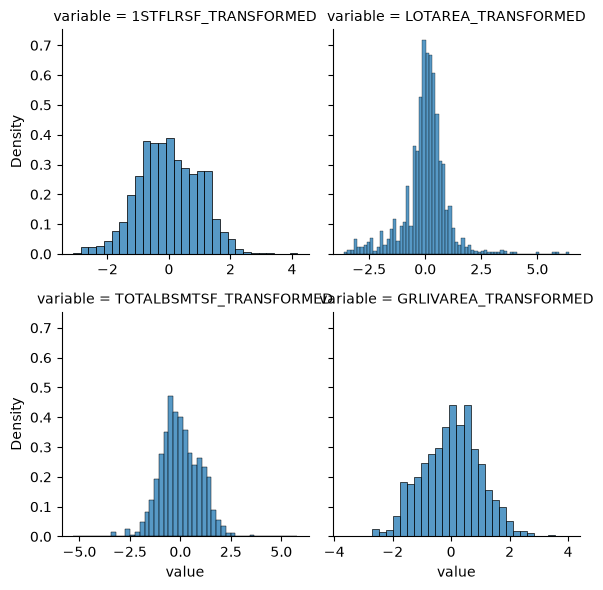

In [2922]:
sns.FacetGrid(
    pd.melt(df_cont, value_vars=pt_cols),
    col="variable",
    col_wrap=2,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value", stat="density")

#### Zero-Heavy Variables → Boolean Flags

In [2923]:
drop_cols = []
add_cols = []

ZERO_PCT_THRESH = 0.70

zero_flag_map = {
    col: "HAS" + col
    for col in zero_df[zero_df["ZERO_PCT"] > ZERO_PCT_THRESH].index
}

for old_col, new_col in zero_flag_map.items():
    df_cont = df_cont.rename(columns={old_col: new_col})
    df_cont[new_col] = np.where(df_cont[new_col] == 0, 0, 1).astype("bool")
    drop_cols.append(old_col)
    add_cols.append(new_col)


zero_heavy_cols = list(set(zero_heavy_cols) - set(drop_cols))
cont_cols = list(set(cont_cols) - set(drop_cols))
bool_cols = list(set(bool_cols).union(set(add_cols)))

#### Remaining Skewed Variables → Log Transform + Presence Flag

In [2924]:
# HANDLE REMAINING VARIABLES (moderate zero presence: bool flag + log1p)
log_flag_map = {col: "HAS" + col for col in zero_heavy_cols}

for old_col, new_col in log_flag_map.items():
    df_cont[new_col] = np.where(df_cont[old_col] == 0, 0, 1).astype("bool")
    df_cont[old_col + "_LOG"] = np.log1p(df_cont[old_col])
    add_cols.append(new_col)

log_cols = [c for c in df_cont.columns if "_LOG" in c]
bool_cols = list(set(bool_cols).union(set(add_cols)))

log_cols

['WOODDECKSF_LOG', 'MASVNRAREA_LOG', 'OPENPORCHSF_LOG', 'BSMTFINSF1_LOG']

#### Summary: High skew treated Columns

In [2925]:
high_skew_final = list(set(pt_cols).union(set(log_cols)))

### Moderate Skew

In [2926]:
zero_df = zero_pct(df_cont, mod_skew_cols)
zero_df.round(2)

,ZERO_PCT
2NDFLRSF,0.56
BSMTUNFSF,0.06


In [2927]:
add_cols = []

df_cont["HAS2NDFLRSF"] = np.where(df_cont["2NDFLRSF"] == 0, 0, 1).astype("bool")

df_cont["2NDFLRSF_LOG"] = np.log1p(df_cont["2NDFLRSF"])
add_cols.append("HAS2NDFLRSF")

bool_cols = list(set(bool_cols).union(set(add_cols)))

In [2928]:
bsmt_unf_pt = PowerTransformer()
df_cont["BSMTUNFSF_TRANSFORMED"] = bsmt_unf_pt.fit_transform(df_cont[['BSMTUNFSF']])[:, 0]

#### Summary: Moderate skew treated Columns

In [2929]:
log_cols = ['2NDFLRSF_LOG']
pt_cols = ['BSMTUNFSF_TRANSFORMED']
mod_skew_final = list(set(pt_cols).union(set(log_cols)))

### Approximately Symmetric Treatment

In [2930]:
zero_df = zero_pct(df_cont, sym_cols)
zero_df.round(2)

,ZERO_PCT
LOTFRONTAGE,0.18
GARAGEAREA,0.05


In [2931]:
sym_final = []
add_cols = []

scaler = StandardScaler()
df_cont['GARAGEAREA_SCALED'] = scaler.fit_transform(df_cont[['GARAGEAREA']])[:, 0]
sym_final.append('GARAGEAREA_SCALED')


df_cont["LOTFRONTAGE_LOG"] = np.log1p(df_cont["LOTFRONTAGE"])
sym_final.append("LOTFRONTAGE_LOG")

df_cont["HASLOTFRONTAGE"] = np.where(df_cont["LOTFRONTAGE"] == 0, 0, 1).astype("bool")
add_cols.append("HASLOTFRONTAGE")
bool_cols = list(set(bool_cols).union(set(add_cols)))

In [2932]:
cont_cols = sym_final

cont_cols = list(set(cont_cols).union(set(mod_skew_final)))
cont_cols = list(set(cont_cols).union(set(high_skew_final)))

### Target Variable (SALEPRICE) — Transformed Separately from Features

In [2933]:
price_pt = PowerTransformer()
df_cont["SALEPRICE_TRANSFORMED"] = price_pt.fit_transform(df_cont[["SALEPRICE"]])

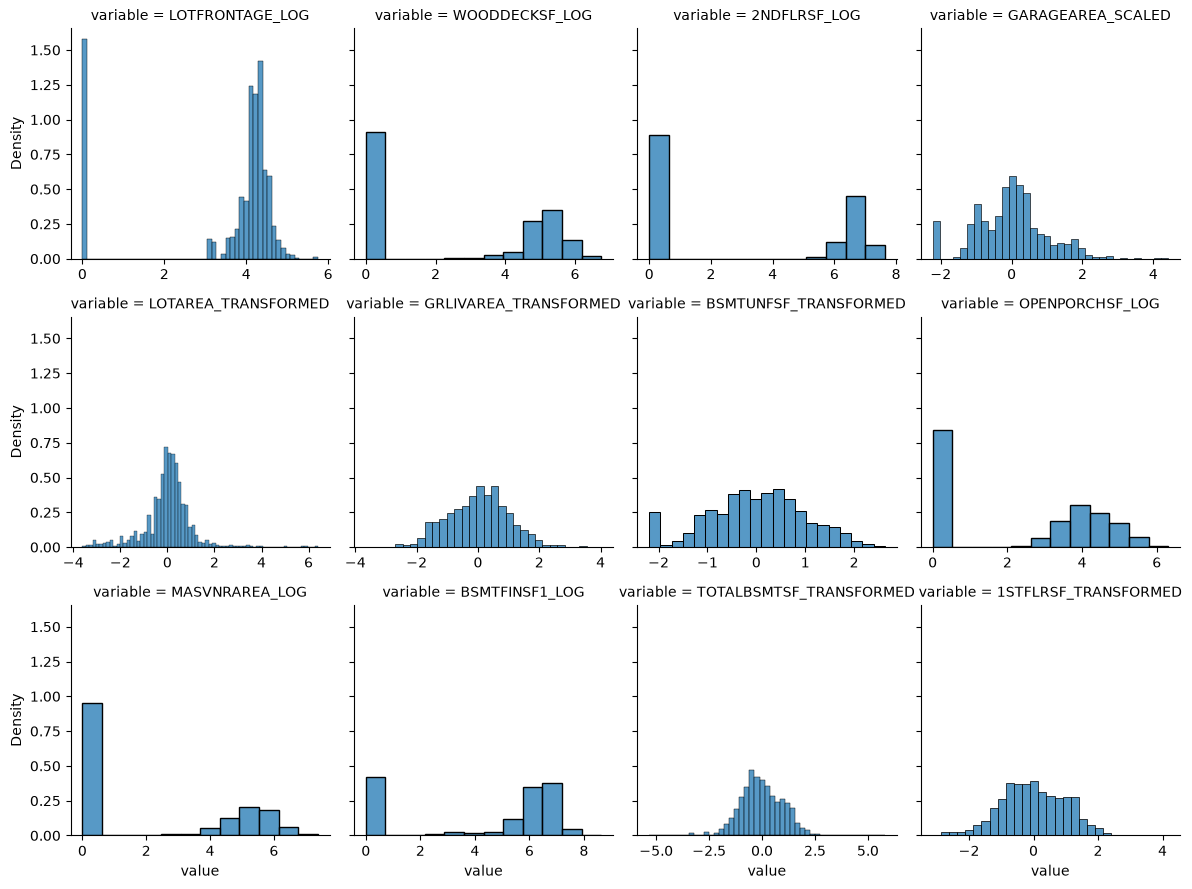

In [2934]:
sns.FacetGrid(
    pd.melt(df_cont, value_vars=cont_cols),
    col="variable",
    col_wrap=4,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value", stat="density")

## Outlier treatment

In [2935]:
zero_df = zero_pct(df_cont, cont_cols)
zero_df = zero_df[zero_df['ZERO_PCT'] > 0]

zero_df

,ZERO_PCT
MASVNRAREA_LOG,0.586402
2NDFLRSF_LOG,0.563739
WOODDECKSF_LOG,0.512040
OPENPORCHSF_LOG,0.441218
BSMTFINSF1_LOG,0.301700
LOTFRONTAGE_LOG,0.177762


In [2936]:
zero_heavy_final_cols = zero_df.index
outlier_cols = list(set(cont_cols) - set(zero_heavy_final_cols))

In [2937]:
df_out = df_cont.copy()

for col in outlier_cols:

    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outliers = (df_out[col] < lower_bound) | (df_out[col] > upper_bound)

    df_out = df_out[~mask_outliers]


pct_removed = round((df_cont.shape[0] - df_out.shape[0]) / df_cont.shape[0] * 100, 2)
print(f"{pct_removed}% removed")

df_cont = df_out.copy()
df_cont.shape[0]

12.25% removed


1239

In [2938]:
df_out = df_cont.copy()

for col in zero_heavy_final_cols:

    non_zero_values = df_cont.loc[df_cont[col] > 0, col]

    Q1 = non_zero_values.quantile(0.25)
    Q3 = non_zero_values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outliers = (df_out[col] == 0) | ((df_out[col] > lower_bound) & (df_out[col] < upper_bound))

pct_removed = round((df_cont.shape[0] - df_out.shape[0]) / df_cont.shape[0] * 100, 2)
print(f"{pct_removed}% removed")
df_cont.shape[0]

0.0% removed


1239

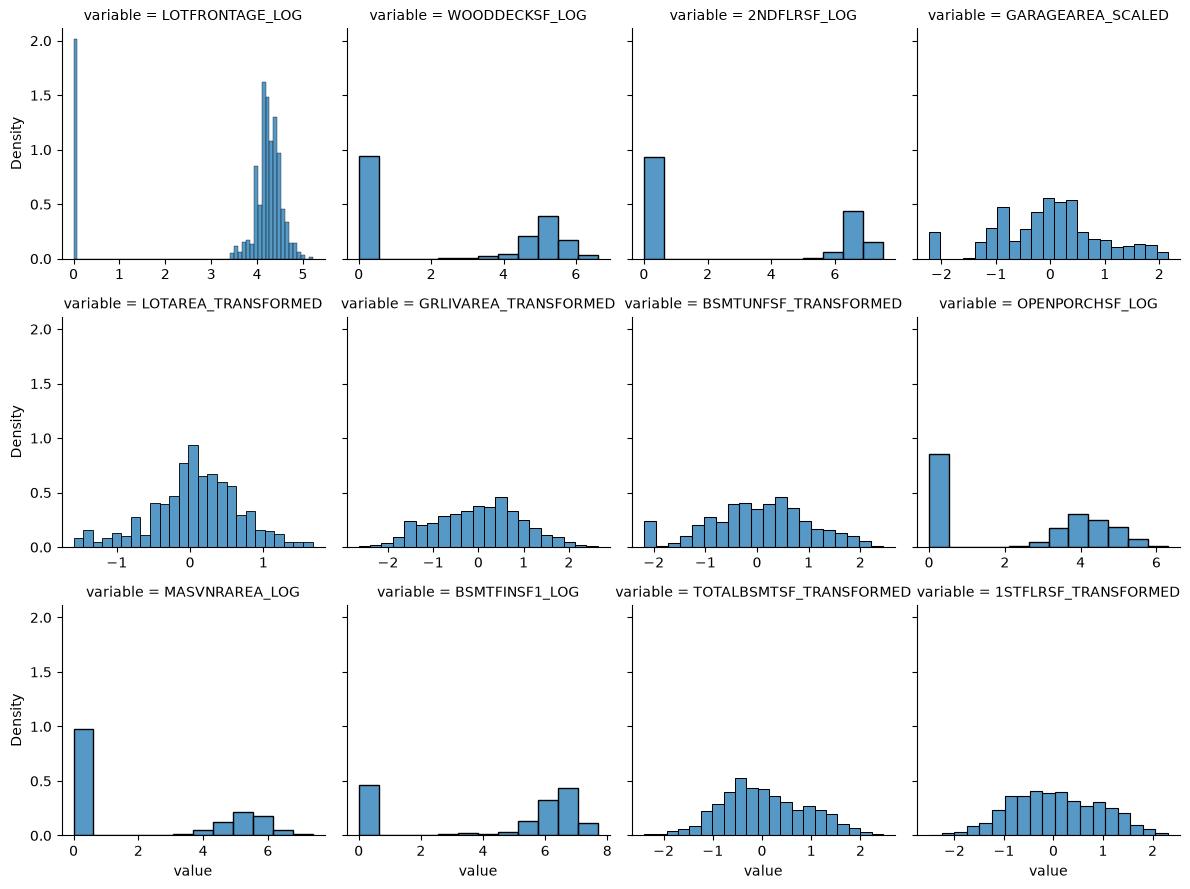

In [2939]:
sns.FacetGrid(
    pd.melt(df_cont, value_vars=cont_cols),
    col="variable",
    col_wrap=4,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value", stat="density")

# Qualitative nominal

In [2940]:
df_nom = df_cont.copy()

for col in nom_cols:
    print(df_nom[col].value_counts().sort_index(ascending=False))
    print()

MSSUBCLASS
190     24
160      8
120     68
90      36
85      19
80      50
75      14
70      55
60     270
50     135
45      12
40       3
30      60
20     485
Name: count, dtype: int64

MSZONING
RM          160
RL         1016
RH           15
FV           40
C (ALL)       8
Name: count, dtype: int64

STREET
PAVE    1236
GRVL       3
Name: count, dtype: int64

ALLEY
PAVE      26
NA      1169
GRVL      44
Name: count, dtype: int64

LANDCONTOUR
LVL    1126
LOW      19
HLS      40
BNK      54
Name: count, dtype: int64

LOTCONFIG
INSIDE     880
FR3          3
FR2         39
CULDSAC     78
CORNER     239
Name: count, dtype: int64

NEIGHBORHOOD
VEENKER     10
TIMBER      31
SWISU       24
STONEBR     22
SOMERST     59
SAWYERW     54
SAWYER      71
OLDTOWN    102
NWAMES      72
NRIDGHT     64
NPKVILL      4
NORIDGE     32
NAMES      208
MITCHEL     42
MEADOWV      3
IDOTRR      32
GILBERT     67
EDWARDS     79
CRAWFOR     46
COLLGCR    147
CLEARCR     14
BRKSIDE     52
BLMNGTN      4
Nam

In [2941]:
for col in nom_cols:
    grp_df = df_nom.groupby(col)['SALEPRICE'].agg(['mean', 'count'])
    grp_df.columns = grp_df.columns.str.upper()
    grp_df = grp_df.rename(columns={'MEAN': 'SALEPRICE_MEAN'})
    grp_df['SALEPRICE_MEAN'] = grp_df['SALEPRICE_MEAN'].round(2)
    grp_df = grp_df.sort_values(by='SALEPRICE_MEAN', ascending=False)
    grp_df['PCT_COUNT'] = round((grp_df['COUNT'] / grp_df['COUNT'].sum()) * 100, 2)
    grp_df['PCT_DIFF'] = grp_df['SALEPRICE_MEAN'].pct_change().round(2) * 100
    grp_df['PCT_DIFF'] = grp_df['PCT_DIFF'].fillna(0)

    grp_df = grp_df[['SALEPRICE_MEAN', 'PCT_DIFF', 'COUNT', 'PCT_COUNT']]
    print(grp_df)
    print("\n", 50*"-", "\n")

            SALEPRICE_MEAN  PCT_DIFF  COUNT  PCT_COUNT
MSSUBCLASS                                            
60               231819.39       0.0    270      21.79
120              200570.09     -13.0     68       5.49
20               182000.44      -9.0    485      39.14
80               171316.40      -6.0     50       4.04
160              170975.00      -0.0      8       0.65
75               169214.29      -1.0     14       1.13
70               165844.38      -2.0     55       4.44
85               145142.11     -12.0     19       1.53
90               141685.03      -2.0     36       2.91
50               141038.49      -0.0    135      10.90
190              126883.33     -10.0     24       1.94
40               121500.00      -4.0      3       0.24
45               108591.67     -11.0     12       0.97
30                98699.18      -9.0     60       4.84

 -------------------------------------------------- 

          SALEPRICE_MEAN  PCT_DIFF  COUNT  PCT_COUNT
MSZONING    

In [2942]:
drop_cols = []
add_cols = []


# CONVERT TO BOOL
df_nom = df_nom.rename(columns={"CENTRALAIR": "HASCENTRALAIR"})
df_nom['HASCENTRALAIR'] = np.where(df_nom['HASCENTRALAIR']=='Y', 1, 0).astype('bool')
drop_cols.append("CENTRALAIR")
add_cols.append("HASCENTRALAIR")

df_nom = df_nom.rename(columns={"ALLEY": "HASALLEY"})
df_nom['HASALLEY'] = np.where(df_nom['HASALLEY']=='NA', 0, 1).astype('bool')
drop_cols.append("ALLEY")
add_cols.append("HASALLEY")

df_nom = df_nom.rename(columns={"STREET": "ISPAVED"})
df_nom['ISPAVED'] = np.where(df_nom['ISPAVED']=='PAVE', 1, 0).astype('bool')
drop_cols.append("STREET")
add_cols.append("ISPAVED")

df_nom = df_nom.rename(columns={"LANDCONTOUR": "FLATNESS"})
df_nom["FLATNESS"] = df_nom["FLATNESS"].map({'HLS': 2, 'LOW': 0, 'LVL': 1, 'BNK': 1})
drop_cols.append("LANDCONTOUR")
add_cols.append("FLATNESS")

# UPDATE NOM_COLS
nom_cols = list(set(nom_cols) - set(drop_cols))
nom_cols = list(set(nom_cols).union({"FLATNESS"}))
bool_cols = list(set(bool_cols).union({"HASCENTRALAIR", "HASALLEY", "ISPAVED"}))
